In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
import copy
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import pccmnn as pc

# ------------------ 你已有的部分 ------------------
csf_dict = pc.load_csf_data()

keys_to_delete = []
for key in csf_dict:
    sample = csf_dict[key]
    sample = sample[~np.isnan(sample).any(axis=1)]   # 删缺失
    csf_dict[key] = sample
    if sample.shape[0] < 2 :
        keys_to_delete.append(key)
for key in keys_to_delete:
    del csf_dict[key]
# ---------------------------------------------------

# ★ 把 numpy 数组转成 patient_data ★
patient_data = {}
for pid, sample in csf_dict.items():
    t = torch.from_numpy(sample[:, 0]).float()            # 年龄
    y = torch.from_numpy(sample[:, 1:5]).float()          # biomarker A/T/N/C
    patient_data[pid] = {"t": t, "y": y, "y0": y[0].clone()}


In [2]:
import torch.nn as nn

class PopulationODE(nn.Module):
    def __init__(self):
        super().__init__()
        self.w = nn.Parameter(torch.randn(21) * 1e-3)

    def f(self, y):
        A, T, N, C = y
        w = self.w
        dA = w[0] + w[1]*A + w[2]*A**2
        dT = (w[3] + w[4]*T + w[5]*T**2 +
              w[6]*A + w[7]*A**2 + w[8]*A*T)
        dN = (w[9] + w[10]*N + w[11]*N**2 +
              w[12]*T + w[13]*T**2 + w[14]*T*N)
        dC = (w[15] + w[16]*C + w[17]*C**2 +
              w[18]*N + w[19]*N**2 + w[20]*N*C)
        return torch.stack([dA, dT, dN, dC])

    def forward(self, s_grid, y0):
        ys = [y0]
        for i in range(1, len(s_grid)):
            h = s_grid[i] - s_grid[i-1]
            ys.append(ys[-1] + h * self.f(ys[-1]))
        return torch.stack(ys)          # (len_s, 4)


In [ ]:
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
from math import ceil

def fit_population(
        patient_data,
        n_adam      = 80,      # adam 阶段迭代次数
        n_lbfgs    = 20,     # lbfgs 阶段迭代次数
        adam_lr_w    = 1e-2,
        adam_lr_ab   = 1e-2,
        lbfgs_lr_w   = 5e-3,
        lbfgs_lr_ab  = 5e-3,
        max_lbfgs_it = 20,
        tolerance_grad = 0,
        tolerance_change = 0):

    # ---------- 初始化 ----------
    model = PopulationODE()
    ab = {pid: {'theta': torch.randn(2, requires_grad=True)}
          for pid in patient_data}

    # --------- Adam 优化器池 -----------
    opt_w_adam  = optim.Adam(model.parameters(), lr=adam_lr_w)
    opt_ab_adam = {pid: optim.Adam([ab[pid]['theta']], lr=adam_lr_ab)
                   for pid in ab}

    # --------- 训练循环 -----------
    for it in range(n_adam + n_lbfgs):
        use_adam = it < n_adam

        # ======================== 更新 w =========================
        if use_adam:
            opt_w_adam.zero_grad()
            loss_w = 0.
            for pid, dat in patient_data.items():
                alpha = torch.exp(ab[pid]['theta'][0]) + 1e-4    # 指数映射代替 softplus
                beta  = ab[pid]['theta'][1]
                s = alpha * dat['t'] + beta
                loss_w += ((model(s, dat['y0']) - dat['y'])**2).mean()
            loss_w.backward()
            opt_w_adam.step()
        else:
            opt_w = optim.LBFGS(model.parameters(), 
                                lr=lbfgs_lr_w,
                                max_iter=max_lbfgs_it, 
                                tolerance_grad=tolerance_grad, 
                                tolerance_change=tolerance_change)

            def closure_w():
                opt_w.zero_grad()
                loss = 0.
                for pid, dat in patient_data.items():
                    alpha = torch.exp(ab[pid]['theta'][0]) + 1e-4
                    beta  = ab[pid]['theta'][1]
                    s = alpha * dat['t'] + beta
                    loss += ((model(s, dat['y0']) - dat['y'])**2).mean()
                loss.backward()
                return loss
            opt_w.step(closure_w)

        # ---------- 可选：估计 σk ----------
        with torch.no_grad():
            res2 = torch.zeros(4); cnt = torch.zeros(4)
            for pid, dat in patient_data.items():
                a = torch.exp(ab[pid]['theta'][0]) + 1e-4
                b = ab[pid]['theta'][1]
                s = a * dat['t'] + b
                r = model(s, dat['y0']) - dat['y']
                res2 += (r**2).sum(0)
                cnt  += torch.tensor(r.shape[0])
            sigma = res2 / cnt.clamp_min(1)

        # ====================== 更新 α,β ==========================
        for pid, dat in patient_data.items():
            if use_adam:
                opt_ab_adam[pid].zero_grad()
                a = torch.exp(ab[pid]['theta'][0]) + 1e-4
                b = ab[pid]['theta'][1]
                s = a * dat['t'] + b
                loss_ab = (((model(s, dat['y0']) - dat['y'])**2) / sigma).mean()
                loss_ab.backward()
                opt_ab_adam[pid].step()
            else:
                opt_ab = optim.LBFGS([ab[pid]['theta']],
                                     lr=lbfgs_lr_ab,
                                     max_iter=max_lbfgs_it, 
                                     tolerance_grad=tolerance_grad, 
                                     tolerance_change=tolerance_change)

                def closure_ab():
                    opt_ab.zero_grad()
                    a = torch.exp(ab[pid]['theta'][0]) + 1e-4
                    b = ab[pid]['theta'][1]
                    s = a * dat['t'] + b
                    loss = (((model(s, dat['y0']) - dat['y'])**2) / sigma).mean()
                    loss.backward()
                    return loss
                opt_ab.step(closure_ab)

        # ----------- 监控 ----------
        if (it+1) % 1 == 0:
            with torch.no_grad():
                total = 0.
                for pid, dat in patient_data.items():
                    a = torch.exp(ab[pid]['theta'][0]) + 1e-4
                    b = ab[pid]['theta'][1]
                    s = a * dat['t'] + b
                    total += ((model(s, dat['y0']) - dat['y'])**2).mean()
            print(f"iter {it+1:02d}/{n_outer} | "
                  f"{'Adam' if use_adam else 'LBFGS'} | "
                  f"MSE={total.item():.4f}")

    # --------- 输出 ----------
    pop_w = model.w.detach().clone()
    alpha_beta = {pid: (float(torch.exp(v['theta'][0])+1e-4),
                        float(v['theta'][1]))
                  for pid, v in ab.items()}
    return pop_w, alpha_beta



In [ ]:
pop_param, ab_dict = fit_population(
    patient_data,)


iter 01/100 | Adam | MSE=2.9824
iter 02/100 | Adam | MSE=2.5987
iter 03/100 | Adam | MSE=2.4895
iter 04/100 | Adam | MSE=2.6095
iter 05/100 | Adam | MSE=2.5600
iter 06/100 | Adam | MSE=2.4134
iter 07/100 | Adam | MSE=2.3881
iter 08/100 | Adam | MSE=2.4553
iter 09/100 | Adam | MSE=2.4508
iter 10/100 | Adam | MSE=2.3709
iter 11/100 | Adam | MSE=2.3245
iter 12/100 | Adam | MSE=2.3504
iter 13/100 | Adam | MSE=2.3804
iter 14/100 | Adam | MSE=2.3539
iter 15/100 | Adam | MSE=2.3008
iter 16/100 | Adam | MSE=2.2863
iter 17/100 | Adam | MSE=2.3095
iter 18/100 | Adam | MSE=2.3149
iter 19/100 | Adam | MSE=2.2860
iter 20/100 | Adam | MSE=2.2570
iter 21/100 | Adam | MSE=2.2531
iter 22/100 | Adam | MSE=2.2609
iter 23/100 | Adam | MSE=2.2562
iter 24/100 | Adam | MSE=2.2374
iter 25/100 | Adam | MSE=2.2226
iter 26/100 | Adam | MSE=2.2192
iter 27/100 | Adam | MSE=2.2166
iter 28/100 | Adam | MSE=2.2073
iter 29/100 | Adam | MSE=2.1960
iter 30/100 | Adam | MSE=2.1881
iter 31/100 | Adam | MSE=2.1818
iter 32/

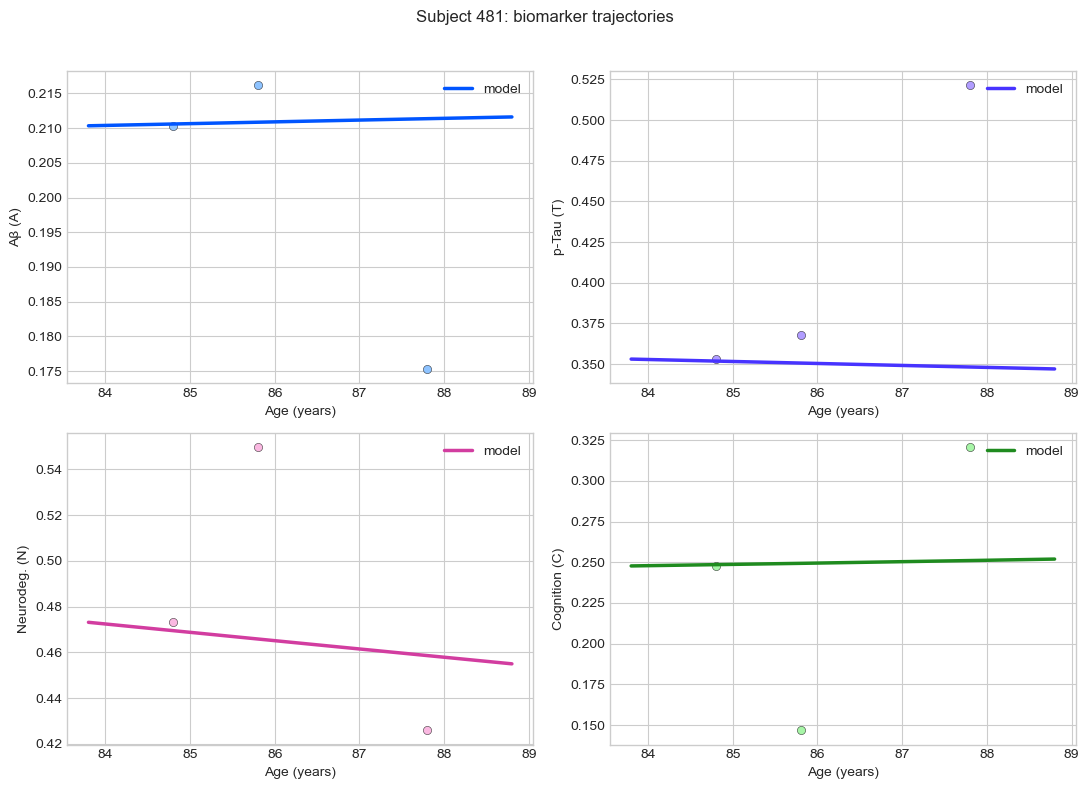

In [5]:
# ---------- 事先确保 trial.py 已经运行完 ----------
# 已经有：
#   • patient_data        —— 所有样本的 {t, y, y0}
#   • pop_param           —— 训练好的 21×1 参数张量
#   • ab_dict             —— 每个 pid 的 (alpha, beta)

import random, math, torch
import matplotlib.pyplot as plt
import numpy as np

# === 1. 重新构建已学好的 ODE 模型 =====================
class PopulationODE(nn.Module):
    def __init__(self, w):
        super().__init__()
        self.w = nn.Parameter(w.clone(), requires_grad=False)  # 固定参数

    def f(self, y):
        A, T, N, C = y
        w = self.w
        dA = w[0] + w[1]*A + w[2]*A**2
        dT = w[3] + w[4]*T + w[5]*T**2 + w[6]*A + w[7]*A**2 + w[8]*A*T
        dN = w[9] + w[10]*N + w[11]*N**2 + w[12]*T + w[13]*T**2 + w[14]*T*N
        dC = w[15] + w[16]*C + w[17]*C**2 + w[18]*N + w[19]*N**2 + w[20]*N*C
        return torch.stack([dA, dT, dN, dC])

    # Euler; 与 trial.py 保持一致
    def forward(self, s_grid, y0):
        ys = [y0]
        for i in range(1, len(s_grid)):
            h = s_grid[i] - s_grid[i-1]
            ys.append(ys[-1] + h * self.f(ys[-1]))
        return torch.stack(ys)

# 实例化固定权重模型
model_fix = PopulationODE(pop_param)

# 颜色：点（浅） / 曲线（深）
COL_LIGHT = ['#8ec3ff',  # 浅蓝
             '#b19dff',  # 蓝紫
             '#fab8e1',  # 粉紫
             '#a7f5a7']  # 浅绿
COL_DARK  = ['#0055ff',  # 深蓝
             '#4733ff',  # 深蓝紫
             '#d23da0',  # 深粉紫
             '#1f8b1f']  # 深绿
TITLES = ['Aβ (A)', 'p-Tau (T)', 'Neurodeg. (N)', 'Cognition (C)']


# ---------- 2. 绘制【单个病例】四联图 -----------------
import random, torch, matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# -------- 随机挑一个“合法”病例，若DPS变换后的s超限则替换下一位 ----------
valid_pids = [p for p in patient_data
              if (torch.abs(ab_dict[p][0] * patient_data[p]['t']
                           + ab_dict[p][1]).max() < 1000)]
pid = random.choice(valid_pids)

a, b = ab_dict[pid]
d  = patient_data[pid]
t_raw, y_raw = d['t'], d['y']
t_dense = torch.linspace(t_raw.min()-1, t_raw.max()+1, 300)
y_hat   = model_fix(a * t_dense + b, d['y0']).numpy()

fig1, axes = plt.subplots(2, 2, figsize=(11, 8))
for k, ax in enumerate(axes.flat):
    ax.scatter(t_raw, y_raw[:, k],
               s=35, c=COL_LIGHT[k], edgecolor='k', linewidth=0.3)
    ax.plot(t_dense, y_hat[:, k],
            lw=2.5, c=COL_DARK[k], label='model')
    ax.set_xlabel('Age (years)'); ax.set_ylabel(TITLES[k])
    ax.legend(frameon=False)
fig1.suptitle(f'Subject {pid}: biomarker trajectories')
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()



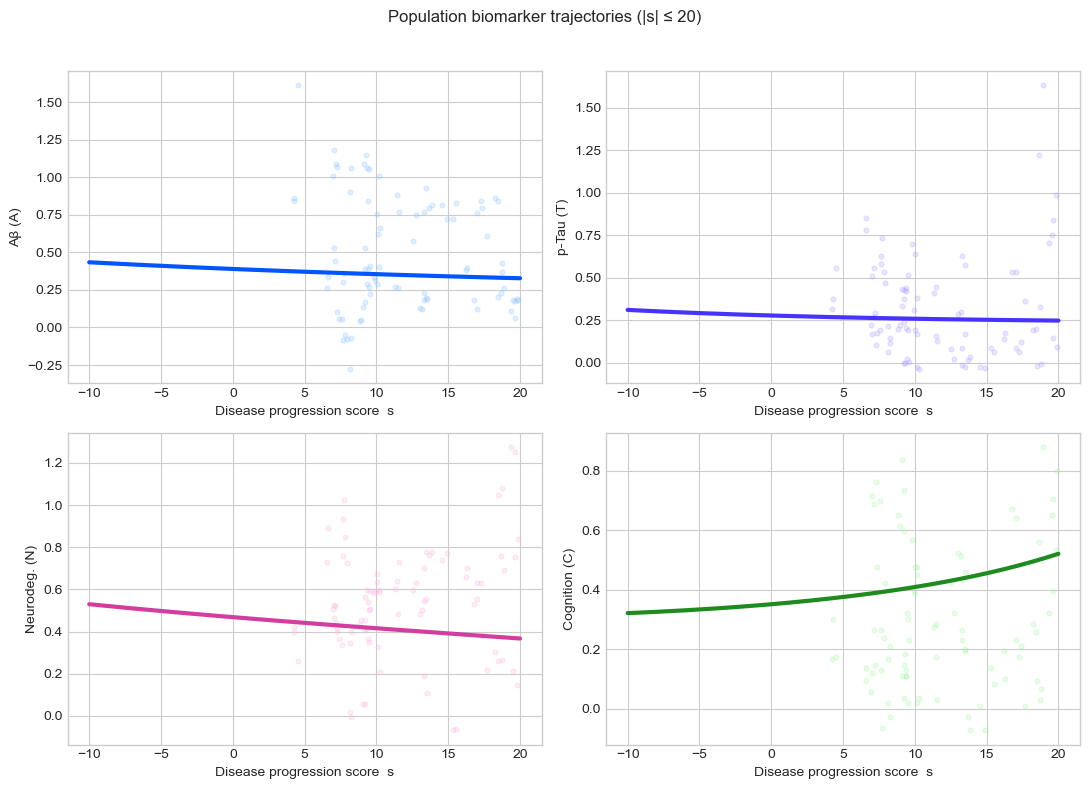

In [6]:
# ---------- 2. 绘制人群四联图 （仅绘制 |s|≤40 的病例） -----------------
# -------- 过滤病例 ---------
keep = [p for p in patient_data
        if (torch.abs(ab_dict[p][0] * patient_data[p]['t']
                      + ab_dict[p][1]).max() < 20)]

y0_pop = torch.stack([patient_data[p]['y0'] for p in keep]).mean(0)
s_curve = torch.linspace(-10, 20, 400)
y_curve = model_fix(s_curve, y0_pop).numpy()

fig2, axes = plt.subplots(2, 2, figsize=(11, 8))
for k, ax in enumerate(axes.flat):
    # 散点
    s_cat, y_cat = [], []
    for p in keep:
        a, b = ab_dict[p]
        s_cat.append(a * patient_data[p]['t'] + b)
        y_cat.append(patient_data[p]['y'][:, k])
    ax.scatter(torch.cat(s_cat).numpy(), torch.cat(y_cat).numpy(),
               s=12, alpha=0.25, c=COL_LIGHT[k])
    # 曲线
    ax.plot(s_curve, y_curve[:, k], lw=3, c=COL_DARK[k])
    ax.set_xlabel('Disease progression score  s'); ax.set_ylabel(TITLES[k])
fig2.suptitle('Population biomarker trajectories (|s| ≤ 20)')
plt.tight_layout(rect=[0,0,1,0.96])

plt.show()
